TODO:
1. každý node max 2 edge (pozměnit generátor grafu)
2. vypracování solveru

 ## preparation of the decomposed automaton

one component
one component
one component
one component
one component


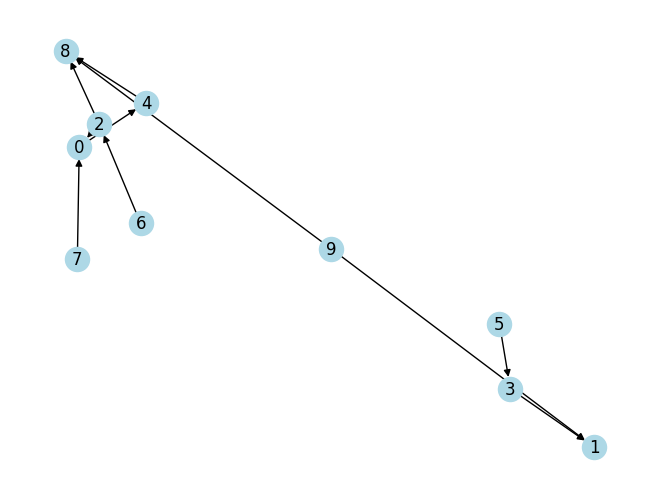

In [1]:
# generate n chains of length m, where n and m are given by the user, default n = 5, m = 10
# fix some order of the chains
# add dependencies on the edges such that the edge of one chain depends on the states of later chains (not the previous ones in the fixed order)
# the number of states on which a given edge depends is chosen uniformly from {0,1, 2, 3}..if there are multiple states, they need to be from different chains.

import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import random

def gen_directed_graphs(n=5, m=10):
    graphs = defaultdict(list)

    for i in range(n):
        G = nx.DiGraph()  # Create a directed graph
        nodes = [j for j in range(m)]  # Create a list of nodes
        # edges = list(zip(nodes[:-1], nodes[1:]))  # Create edges between consecutive nodes

        # make sure the edge is not a loop
        # edges = [(random.choice(nodes), random.choice(nodes)) for _ in range(m)]
        used_nodes = set()
        edges = []

        while len(edges) < m:
            pos1 = random.choice(nodes)
            pos2 = random.choice(nodes)

            if (pos1, pos2) not in edges and (pos2, pos1) not in edges and pos1 != pos2:
                edges.append((pos1, pos2))
                used_nodes.add(pos1)
                used_nodes.add(pos2)

                # If we're about to finish but haven't used all nodes,
                # reject this attempt and start over
                remaining_edges = m - len(edges)
                unused_nodes = set(nodes) - used_nodes
                if remaining_edges < len(unused_nodes):
                    edges = []
                    used_nodes = set()

        # filter out edges from edges that loop
        # edges = [(u, v) for u, v in edges if u != v]
        
        # Assign random directions to edges
        random_edges = set()

        for u, v in edges:
            if random.choice([True, False]):  # Randomly decide the direction
                random_edges.add((u, v))
            else:
                random_edges.add((v, u))

        random_edges = list(random_edges)
        
        
        G.add_edges_from(random_edges)  # Add edges with random directions

        if(nx.number_weakly_connected_components(G) > 1):
            
            main_component = max(nx.weakly_connected_components(G), key=len)  # Find the largest connected component
            print(nx.number_weakly_connected_components(G))
            print(f"Main connected component: {main_component}")
            # iterate through weakly connected components aside the main one
            for component in [c for c in nx.weakly_connected_components(G) if c != main_component]:
                num_of_connections = random.randint(1, len(component))
                print(f"Weakly connected component: {component}")
                # choose random nodes from the component based on num_of_connections
                random_nodes = random.sample(sorted(component), num_of_connections)
                # connect each node from random_nodes to random node from the main component
                for node in random_nodes:
                    G.add_edge(node, random.choice(list(main_component)))

        else:
            print("one component")

        graphs[i] = G
        
    return graphs

def add_enabling(chains):
    n = len(chains)
    
    for chain_id in range(n-1):
        G = chains[chain_id]
        
        for edge in G.edges():
            if random.random() < 0.5:

                number_of_groups = random.randint(1,3)
                group_conditions = []

                for x in range(number_of_groups):

                    num_deps = random.randint(1, 3)
                    
                    later_chains = list(range(chain_id + 1, n))
                    selected_chains = random.sample(later_chains, min(num_deps, len(later_chains)))
                    
                    enabling_conditions = []

                    for enabling_chain in selected_chains:
                        enabling_G = chains[enabling_chain]
                        enabling_node = random.choice(list(enabling_G.nodes()))
                        enabling_conditions.append({'automata_id':enabling_chain,'node_id':enabling_node})

                    group_conditions.append(enabling_conditions)
                
                G.edges[edge]['enabling'] = group_conditions if len(group_conditions) > 0 else None
    
    return chains

graphs = add_enabling(gen_directed_graphs())

nx.draw(graphs[0], with_labels=True, node_color='lightblue', arrows=True)
plt.show()

In [2]:
for chain_id in range(len(graphs)):
    print(f"\nChain {chain_id}:")
    G = graphs[chain_id]
    for edge in G.edges(data=True):
        print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")

# Edge 7 -> 2: {'enabling': [[{'automata_id': 3, 'node_id': 5}, {'automata_id': 1, 'node_id': 3}], [{'automata_id': 1, 'node_id': 7}, {'automata_id': 3, 'node_id': 5}], [{'automata_id': 3, 'node_id': 9}, {'automata_id': 1, 'node_id': 9}, {'automata_id': 2, 'node_id': 8}]]}
# [4 7 3 7] -> [[9 8 9 2], [3 5 2 0], ... ]
# chain 3 -> node 5
# chain 1 -> node 3
# OR
# chain 1 -> node 7
# chain 3 -> node 5
# OR
# chain 3 -> node 9
# chain 1 -> node 9
# chain 2 -> node 8
# solve(sample = [1 1 1 3], target_node = 5)
#   target_chain = len(sample)
#   current_state = sample.copy()
#   paths_lst = get_all_paths(current_state[target_chain], target_node)
#    for i, path in enumerate(paths_lst): # 3 4 5
#        projdu hrany po ceste (3-4), ziskam enabling
#        pokud neexistuje enabling, projdu edge
#        pokud existuje enabling, tak treba automat 1 ma byt ve stavu 2 a automat 2 ma byt ve stavu 3
#        prvni vyresime prvni pravidlo a pak druhe
#        for rule_set in rules:
#            found = True
    #        for rule in sorted(rule_set): # sorted znamena setrizene od nejvice zavisleho po nejmene
            #    current_sub_state = solve(current_state[:target_chain], target_node = 5)
            #    if current_sub_state == None:
            #       found = False
            #       break
            #    current_state[:target_chain] = current_sub_state
            #if found:
            #   break
    #return current_state     
        #    
    
# nx.get_simple_paths(3, 5) 


Chain 0:
Edge 6 -> 2: {}
Edge 2 -> 0: {'enabling': [[{'automata_id': 4, 'node_id': 6}, {'automata_id': 3, 'node_id': 8}, {'automata_id': 2, 'node_id': 5}], [{'automata_id': 3, 'node_id': 7}, {'automata_id': 2, 'node_id': 9}], [{'automata_id': 2, 'node_id': 4}]]}
Edge 2 -> 8: {'enabling': [[{'automata_id': 2, 'node_id': 0}], [{'automata_id': 4, 'node_id': 9}, {'automata_id': 3, 'node_id': 4}, {'automata_id': 2, 'node_id': 5}]]}
Edge 0 -> 4: {'enabling': [[{'automata_id': 1, 'node_id': 2}], [{'automata_id': 4, 'node_id': 2}, {'automata_id': 3, 'node_id': 6}, {'automata_id': 2, 'node_id': 9}]]}
Edge 4 -> 8: {}
Edge 3 -> 1: {'enabling': [[{'automata_id': 3, 'node_id': 2}, {'automata_id': 4, 'node_id': 1}, {'automata_id': 2, 'node_id': 1}]]}
Edge 7 -> 0: {}
Edge 9 -> 8: {}
Edge 9 -> 1: {'enabling': [[{'automata_id': 2, 'node_id': 9}], [{'automata_id': 1, 'node_id': 4}, {'automata_id': 2, 'node_id': 3}], [{'automata_id': 2, 'node_id': 1}, {'automata_id': 3, 'node_id': 2}]]}
Edge 5 -> 3: {'e

## creation of 1 sample problem

In [24]:
a = [1,2,3]
a.index(2)

1

In [3]:
from itertools import product
def get_vectors(chains):
    states_per_chain = []
    for chain_id in range(len(chains)):
        states_per_chain.append(list(chains[chain_id].nodes()))
    
    return list(product(*states_per_chain))

vecs = get_vectors(graphs)
print(len(vecs))
print(vecs[0])

100000
(6, 1, 1, 3, 4)


In [4]:
from tqdm import tqdm
id_2_vec = {}
vec_2_id = {}
for i, comb in tqdm(enumerate(vecs)):
    id_2_vec[i] = comb
    vec_2_id[comb] = i

0it [00:00, ?it/s]

100000it [00:00, 2646465.64it/s]


In [5]:
def get_sample(vector, graphs):
    num_states = len(graphs[0].nodes())
    vec = list(vector)  # [1,2,3,4]
    for i in range(num_states):
        if vec[0] != i:
            yield vec, i

In [ ]:
def solve(curr_states, target_node, graphs, orig_state_len, log=[], depth=0):
    '''
    Solves the problem of reaching target node from current state in graphs by returning the resulting state and log of steps.
    Parameters:
        curr_states: list of current states of automatas; LIST of INTEGERS
        target_node: target node; INTEGER
        graphs: list of graphs; LIST of networkx graphs
        log: list of log messages; LIST of STRINGS
        depth: depth of recursion; INTEGER
    Returns:
        out: states of automatas after solving or None if no solution; LIST of INTEGERS/None
            out: log: list of log messages; LIST of STRINGS
    '''
    indent = ' '*depth*2
    # log.append(f"{'-'*50}")
    curr_states_cpy = curr_states.copy()
    log.append(f"{indent}S {curr_states_cpy} TN {target_node}")
    # get all paths from current state to target node
    paths_lst = list(nx.all_simple_paths(graphs[0], curr_states_cpy[0], target_node))
    
    # check if there is a path
    if len(paths_lst) == 0:
        log.append(f"{indent}NOPATH {curr_states} TN {target_node}")
        return None, log
    
    # check if current node equals target node
    if curr_states_cpy[0] == target_node:
        log.append(f"{indent}REND {curr_states_cpy}")
        return curr_states_cpy, log
    
    # path or paths exist and we are not in target node
    for path in paths_lst:
        log.append(f"{indent}P {path}")
        # projdu hrany po ceste (3-4), ziskam enabling
        curr_states_cpy = curr_states.copy()
        rules = graphs[0].get_edge_data(curr_states_cpy[0], path[1])
        # pokud neexistuje enabling, projdu edge
        log.append(f"{indent}RLS {rules}")
        if rules == {}:
            log.append(f"{indent}NOR {curr_states_cpy} TN {target_node}")
            # pokud má path jeden node, tak je to konec
            curr_states_cpy[0] = path[1]
            log.append(f"{indent}NORCH {curr_states_cpy}")

            return solve(curr_states_cpy, target_node, graphs, orig_state_len, log, depth+1)

        # pokud existuje enabling, tak treba automat 1 ma byt ve stavu 2 a automat 2 ma byt ve stavu 3
        # prvni vyresime prvni pravidlo a pak druhe
        else:
            for rule_set in rules['enabling']:
                log.append(f"{indent}RS {rule_set}")

                curr_states_cpy = curr_states.copy()
                found = True

                for rule in sorted(rule_set, key=lambda x: x['automata_id']): # sorted znamena setrizene od nejvice zavisleho po nejmene
                    log.append(f"{indent}RULE {rule}")
                    idx = max(rule['automata_id'] - (orig_state_len - len(curr_states_cpy)), 0)
                    log.append(f"{indent}IDX {idx} LEN {len(curr_states_cpy)}")
                    current_sub_state, log = solve(curr_states_cpy[idx:], rule['node_id'], graphs[idx:], orig_state_len, log, depth+1)

                    log.append(f"{indent}RCH {current_sub_state}")
                    if current_sub_state == None:
                        found = False
                        break
                    log.append(f"{indent}SUB {curr_states_cpy}")
                    curr_states_cpy[rule['automata_id']:] = current_sub_state
                    log.append(f"{indent}SUBCH {curr_states_cpy}")

                if found:
                    log.append(f"{indent}SUBF {curr_states_cpy}")
                    curr_states_cpy[0] = path[1]
                    log.append(f"{indent}SUBSOLVED {curr_states_cpy}")
                    break
                else:
                    continue
            
            if found:
                return solve(curr_states_cpy, target_node, graphs, orig_state_len, log, depth+1)
            else:
                continue
    log.append(f"{indent}UNSOL {curr_states_cpy}")            
    return None, log

In [7]:
indexes = list(range(len(vecs)))
samples = []

In [8]:
a = [1,2,3]
a[1:]

[2, 3]

In [21]:
from pprint import pprint

log = []
curstate, log = solve([2,6,4,3,2], 0, list(graphs.values()), log)
pprint(log)

0 [] 5


UnboundLocalError: cannot access local variable 'paths_lst' where it is not associated with a value

In [270]:
log = []
for i in indexes:
    for sample in get_sample(vecs[i], graphs):
        sample_log = []  # ONE list for this sample
        sample_log.append(f"START {sample}")
        curstate, targetnode = sample
        curstate, solve_log = solve(curstate, targetnode, graphs, [])
        if solve_log:
            sample_log.extend(solve_log)
        sample_log.append(f"END {curstate}")
        log.append(sample_log)  # Add this ONE sample list to the main list

In [271]:
from pprint import pprint
pprint(log)

[['START ([9, 1], 0)', 'END None'],
 ['START ([9, 1], 1)',
  'P [9, 1]',
  "RLS {'enabling': [[{'automata_id': 1, 'node_id': 7}], [{'automata_id': 1, "
  "'node_id': 8}]]}",
  "RS [[{'automata_id': 1, 'node_id': 7}], [{'automata_id': 1, 'node_id': 8}]]",
  "RG [{'automata_id': 1, 'node_id': 7}]",
  "RULE {'automata_id': 1, 'node_id': 7}",
  'R [9, 1] TN 9',
  'RCH [9, 1]',
  'NPATH [9, 1] TN 9',
  'REND [9, 1]',
  'SUBSOLVED [1, 1]',
  'END None'],
 ['START ([9, 1], 2)', 'END None'],
 ['START ([9, 1], 3)', 'END None'],
 ['START ([9, 1], 4)', 'END None'],
 ['START ([9, 1], 5)', 'END None'],
 ['START ([9, 1], 6)', 'END None'],
 ['START ([9, 1], 7)', 'END None'],
 ['START ([9, 1], 8)', 'END None'],
 ['START ([9, 2], 0)', 'END None'],
 ['START ([9, 2], 1)',
  'P [9, 1]',
  "RLS {'enabling': [[{'automata_id': 1, 'node_id': 7}], [{'automata_id': 1, "
  "'node_id': 8}]]}",
  "RS [[{'automata_id': 1, 'node_id': 7}], [{'automata_id': 1, 'node_id': 8}]]",
  "RG [{'automata_id': 1, 'node_id': 7}]

## implementation of the solver

In [272]:
steps_log = []
shortest_paths_log = []
target_log = []

def get_rule(chains, target_chain, cur_node, next_node):
    cur_rule = chains[target_chain].get_edge_data(cur_node, next_node)
    steps_log.append((target_chain, cur_node, next_node, cur_rule))
    return cur_rule

def get_shortest_path(chains, target_chain, current_state, target_state):
    shortest_path = nx.shortest_path(chains[target_chain],current_state[target_chain], target_state)
    shortest_paths_log.append((target_chain,shortest_path))
    return shortest_path

def solve(sample, chains, path=[]):
    target_chain = sample["target_chain"]
    target_state = sample["target_state"]
    target_log.append((target_chain, target_state))
    current_state = list(sample["input"])
    shortest_paths = get_shortest_path(chains, target_chain, current_state, target_state)
    for i, cur_node in enumerate(shortest_paths):
        if i < len(shortest_paths)-1:
            next_node = shortest_paths[i+1]
            cur_rule = get_rule(chains, target_chain, cur_node, next_node)
            if cur_rule == {}:
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node

                continue
            else:
                for rules in cur_rule["enabling"]:
                    new_sample = {}
                    new_sample['input'] = current_state
                    new_sample["target_state"] = rules["node_id"]
                    new_sample['target_chain'] = rules["automata_id"]
                    path, current_state = solve(new_sample, chains, path)
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node
                # after each dependency state is resolved, cross the edge and append it to the path and change the current state
                # after the shortest path to the target state if traversed, return the path and the current state
    return path, current_state

    # for the target chain, find all shortest paths from the current state to the target state
    # take the first path and try to traverse it. ie iterate over the edges and do the following:
    # # if the edge is not dependent on other states:
    # # # cross the edge, i.e. change the current state for the target chain to get one more step closer to the target state
    # # # path.append(edge)
    # # else get the dependency states, depenendet = edge['enabling']
    # # for each dependency state, do the following:
    # # # new_sample = {}
    # # # new_sample['input_states'] = current_state
    # # # new_sample["target"] = dependency_state
    # # # new_sample['target chain'] = chain of the dependency state
    # # # path, current_state = solve(new_sample,path)
    # # after each dependency state is resolved, cross the edge and append it to the path and change the current state
    # after the shortest path to the target state if traversed, return the path and the current state

## implementation of the complex solver

In [273]:
rules = ['a', 'b', 'c']
result = []
for rule in rules:
    combinations = []
    combinations.append(rule)
    for rule_2 in rules:
        if rule != rule_2:
            combinations.append(rule_2)

    result.append(combinations)

print(result)

[['a', 'b', 'c'], ['b', 'a', 'c'], ['c', 'a', 'b']]


In [274]:
def get_rule(graphs, target_graph, cur_node, next_node):
    cur_rule = graphs[target_graph].get_edge_data(cur_node, next_node)
    return cur_rule

def get_all_possible_rule_combinations(rules):
    combinations = []

    return combinations

def get_available_paths(graphs, target_graph, current_state, target_state):
    return nx.all_simple_paths(graphs[target_graph], current_state[target_graph], target_state)

def solve_complex(sample, graphs, current_path=[], paths=[]):
    target_graph = sample['target_graph']
    target_state = sample['target_state']
    current_state = list(sample["input"])

    available_paths = get_available_paths(graphs, target_graph, current_state, target_state)

    for path in available_paths:
        is_valid = nx.has_path(graphs[target_graph], current_state[target_graph], target_state)

        if is_valid:

            for i, cur_node in enumerate(path):
                if i < len(path)-1:
                    next_node = path[i+1]
                    cur_rule = get_rule(graphs, target_graph, cur_node, next_node)
                    if cur_rule == {}:
                        current_path.append({"automata_id": target_graph, "state_change": (cur_node, next_node)})
                        current_state[target_graph] = next_node
                        continue

                    else:
                        for rule_group in cur_rule["enabling"]:
                            rules_combinations = get_all_possible_rule_combinations(rule_group)
                            for rule_combinations in rules_combinations:
                                for rule in rule_combinations:
                                    new_sample = {}
                                    new_sample['input'] = current_state
                                    new_sample["target_state"] = rule["node_id"]
                                    new_sample['target_graph'] = rule["automata_id"]
                                    current_path, paths, current_state = solve_complex(new_sample, graphs, current_path, paths)
                                current_path.append({"automata_id": target_graph, "state_change": (cur_node, next_node)})
                                current_state[target_graph] = next_node

        else:
            paths.append(None)

        paths.append((current_path, current_state))
    
    return current_path, paths, current_state

# check if a path from start to target node exists in target graph
# if path exists:
# # get all paths from start to target node
# # iterate over the paths:
# # # iterate over the edges:
# # # # if the edge is not dependent on other states:
# # # # # cross the edge, i.e. change the current state for the target chain to get one more step closer to the target state
# # # # # current_path.append(edge)
# # # # else get the dependency groups, depenendet = edge['enabling']
# # # # # iterate over the dependency groups:
# # # # # # create a list of all possible combinations of dependencies in group:
# # # # # # # iterate over every combination:
# # # # # # # # .....
# else:
# # path doesn't exist, return None

In [275]:
solver_paths = solve_complex

In [276]:
solver_path = solve(sample, graphs)
solver_path, len(solver_path[0])

TypeError: tuple indices must be integers or slices, not str

In [ ]:
def group_automata(data):
    changes, finals = data
    result = []
    
    for change in changes:
        if result and result[-1]['automata_id'] == change['automata_id']:
            result[-1]['state_change'].append(change['state_change'])
        else:
            result.append({'automata_id': change['automata_id'], 
                         'state_change': [change['state_change']]})
            
    return (result, finals)

In [ ]:
def group_rules(data):
    result = []
    
    for rule in data:
        if result and result[-1]['automata_id'] == rule[0]:
            result[-1]['state_change'].append(((rule[1], rule[2]), rule[3]))
        else:
            result.append({'automata_id': rule[0],  
                         'state_change': [((rule[1], rule[2]), rule[3])]})
            
    return result

In [ ]:
rules_grp = group_rules(steps_log)
rules_grp, len(rules_grp)

In [ ]:
path_grp = group_automata(solver_path)
path_grp, len(path_grp[0])

In [ ]:
print([x['automata_id'] for x in rules_grp])
print([x['automata_id'] for x in path_grp[0]])

In [ ]:
used_rules = []
for x in rules_grp:
    for y in x['state_change']:
        if y[1] != {}:
            used_rules.append((x['automata_id'],y))
for rule in used_rules:
    print(rule)
len(used_rules)

In [ ]:
target_log,len(target_log)

In [ ]:
def find_origin(condition):
    for rule in used_rules:
        for enabling in rule[1][1]['enabling']:
            if (enabling['automata_id'], enabling['node_id']) == condition:
                return (rule[0], rule[1][0])
            
    return None

***Prepare data for visualization***

In [ ]:
# delete row in shortest_paths_log that contains only one instance
shortest_paths_log = [x for x in shortest_paths_log if len(x[1]) > 1]
shortest_paths_log, len(shortest_paths_log)

In [ ]:
full_path = []
previous_states = [state for state in sample['input']]
states = [state for state in sample['input']]
rules_grp_tmp = [x for x in rules_grp]

last_automata_id = path_grp[0][0]['automata_id']
last_next_state = path_grp[0][0]['state_change'][0][1]
shortest_paths_log_tmp = [(item[0], [i for i in item[1]]) for item in shortest_paths_log]

# BEGINNING PHASE
# Add steps that only show edges with conditions, no state change
for ruul in rules_grp_tmp:

    if ruul['automata_id'] != path_grp[0][0]['automata_id']:
        rules_grp_tmp = rules_grp_tmp[1:]
        for item in shortest_paths_log_tmp:
            if item[0] == ruul['automata_id'] and item[1] != []:
                current_shortest_path = item[1][:]
                break

        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                                'automata_id': ruul['automata_id'],
                                'states': [state for state in states],
                                'next_state': ruul['state_change'][0][0][0],
                                'shortest_path': current_shortest_path,
                                'edge': ruul['state_change'][0][0],
                                'conditions': {},
                                'debug_ID': "a",})
    else:
        break

# MAIN PHASE
for rules in path_grp[0]:
    
    # Assign current shortest path
    for item in shortest_paths_log_tmp:
        if item[0] == rules['automata_id'] and item[1] != []:
            current_shortest_path = item[1][:]
            item[1][:len(rules['state_change'])+1] = []
            break

    for i, state_change in enumerate(rules['state_change']):
        # Update state of last automata, needed when switching from one automata to other
        # states[last_automata_id] = last_next_state
        states[rules['automata_id']] = state_change[0]

        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'shortest_path': current_shortest_path[:],
                            'edge': state_change,
                            'conditions': {},
                            'debug_ID': "b",})
        current_shortest_path[:1] = []

        # Look at the upcoming edge if it has a condition
        # if item[1] != [] and state_change[1] == current_shortest_path[-1]:
        #     a = item[1][0]
        #     rule_exists = chains[rules['automata_id']][state_change[1]][a] != {}
        #     current_state_not_target = rules['automata_id'] != sample['target_chain'] or state_change[1] != sample['target_state']
        #     if rule_exists and current_state_not_target:
        #         rule = True
        #         states[rules['automata_id']] = state_change[1]
        #         status = "solving"
        #         solving_rules[rules['automata_id']] = {(state_change[1], a): {target_log_temp[0]: status}}
        #         full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
        #                         'automata_id': rules['automata_id'],
        #                         'states': [state for state in states],
        #                         'next_state': state_change[1],
        #                         'shortest_path': current_shortest_path,
        #                         'edge': (state_change[1], a),
        #                         'conditions': copy.deepcopy(solving_rules),
        #                         'debug_ID': "c",})
        #         target_log_temp = target_log_temp[1:]
        
        last_automata_id = rules['automata_id']
        last_next_state = state_change[1]

    if(len(current_shortest_path) >= 2):

        states[rules['automata_id']] = state_change[1]
        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'shortest_path': current_shortest_path,
                            'edge': (state_change[1], current_shortest_path[1]),
                            'conditions': {},
                            'debug_ID': "d",})
    else:
        states[rules['automata_id']] = state_change[1]
        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'conditions': {},
                            'debug_ID': "e",})
        
    # for ruul in rules_grp_tmp:

    #     if ruul['automata_id'] != path_grp[0][0]['automata_id']:
    #         print(ruul['automata_id'])
    #         print(path_grp[0][0]['automata_id'])
            
    #         for item in shortest_paths_log_tmp:
    #             if item[0] == ruul['automata_id'] and item[1] != []:
    #                 current_shortest_path = item[1][:]
    #                 break

    #         full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
    #                                 'automata_id': ruul['automata_id'],
    #                                 'states': [state for state in states],
    #                                 'next_state': ruul['state_change'][0][0][0],
    #                                 'shortest_path': current_shortest_path,
    #                                 'edge': ruul['state_change'][0][0],
    #                                 'debug_ID': "f",})
    #     else:
    #         rules_grp_tmp = rules_grp_tmp[1:]
    #         break


visited = set()
solving_rules = {}

for i, state in enumerate(full_path[0]['states']):
    visited.add((i, state))

# Logic for conditions

for condition in used_rules:
    for enabling in condition[1][1]['enabling']:
        val = None
        
        for i, step in enumerate(full_path):

            if 'shortest_path' in step and step['automata_id'] == enabling['automata_id'] and step['shortest_path'][-1] == enabling['node_id']:
                val = "solving"
            
            print(i)
            if step['automata_id'] == enabling['automata_id'] and 'shortest_path' not in step and step['states'][step['automata_id']] == enabling['node_id']:
                val = "solved"

            if val != None:
                if condition[0] not in step['conditions']:
                    step['conditions'][condition[0]] = {}

                if condition[1][0] not in step['conditions'][condition[0]]:
                    step['conditions'][condition[0]][condition[1][0]] = {}

                step['conditions'][condition[0]][condition[1][0]][(enabling['automata_id'], enabling['node_id'])] = val

            # step['conditions'] = copy.deepcopy(solving_rules)

# for item in full_path:

#     if "edge" in item:
#         if chains[item['automata_id']].edges[item['edge']] != {}:

#             if item['automata_id'] not in solving_rules:
#                 solving_rules[item['automata_id']] = {}

#             if item['edge'] not in solving_rules[item['automata_id']]:
#                 solving_rules[item['automata_id']][item['edge']] = {}
            
#             for condition in chains[item['automata_id']].edges[item['edge']]['enabling']:
#                 # if (condition['automata_id'], condition['node_id']) not in solving_rules[item['automata_id']][item['edge']]:
#                 if (condition['automata_id'], condition['node_id']) in visited:
#                     val = "solved"
#                 else:
#                     val = "solving"

#                 solving_rules[item['automata_id']][item['edge']][(condition['automata_id'], condition['node_id'])] = val

#     item['conditions'] = copy.deepcopy(solving_rules)

# Last step
# full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
#                             'automata_id': rules['automata_id'],
#                             'states': path_grp[1],
#                             'next_state': state_change[1],})

# full_path, len(full_path)

In [ ]:
full_path, len(full_path)

In [ ]:
# print(full_path[7])
# print(full_path[8])
# print(full_path[11])
# print(full_path[18])
# print(full_path[19])
# print(full_path[20])
# print(full_path[21])
# print(full_path[22])

**Visualization**

In [ ]:
import visualize_search as vs
import importlib

importlib.reload(vs)

visualization = vs.Visualize_search(graphs, full_path, sample['input'])
visualization.animate("test_visualization")